# SAM Segmentation

Instance masks for detected mobs. YOLO provides the box (ROI); SAM turns it into a pixel mask. No segmentation training required.

In [1]:
from pathlib import Path
import sys

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().resolve().parent.parent))
import src.config as cfg
from ultralytics import YOLO, SAM

DEVICE = 0 if torch.cuda.is_available() else "cpu"

SAM_MODEL = cfg.ROOT_DIR / "pretrained_models" / "mobile_sam.pt"
if not SAM_MODEL.exists():
    SAM_MODEL = "mobile_sam.pt"

DET_MODEL = next(cfg.ROOT_DIR.glob("notebooks/**/weights/best.pt"))

sam = SAM(str(SAM_MODEL))
print("device:", DEVICE)
print("detector:", DET_MODEL.relative_to(cfg.ROOT_DIR))

device: 0
detector: notebooks\3_experimentos\runs\detect\train\weights\best.pt


In [2]:
COLORS = [(0, 255, 0), (0, 165, 255), (255, 0, 255), (255, 255, 0), (0, 0, 255)]


def imread_unicode(path):
    return cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), cv2.IMREAD_COLOR)


def overlay_masks(image, masks, boxes=None, labels=None):
    out = image.copy()
    for i, m in enumerate(masks):
        color = COLORS[i % len(COLORS)]
        mb = m.astype(bool)
        out[mb] = (0.45 * out[mb] + 0.55 * np.array(color)).astype(np.uint8)
        cnts, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, cnts, -1, color, 2)
    if boxes is not None:
        for j, (x1, y1, x2, y2) in enumerate(boxes):
            cv2.rectangle(out, (int(x1), int(y1)), (int(x2), int(y2)), (255, 255, 255), 1)
            if labels:
                cv2.putText(out, str(labels[j]), (int(x1), max(int(y1) - 5, 12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    return out


def show(image_bgr, title=""):
    plt.figure(figsize=(9, 6))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def highlight(image, mask):
    out = (image * 0.3).astype(np.uint8)
    mb = mask.astype(bool)
    out[mb] = image[mb]
    return out


def cutout_rgba(image, mask):
    rgba = cv2.cvtColor(image, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask.astype(np.uint8) * 255
    return rgba


def mask_to_polygon(mask):
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return []
    return max(cnts, key=cv2.contourArea).reshape(-1, 2).tolist()

## 1. SAM with ground-truth boxes

Isolates SAM quality using perfect ROIs from the dataset labels.

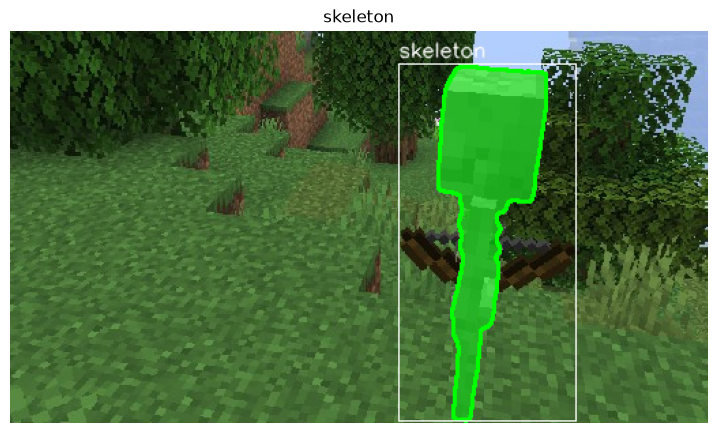

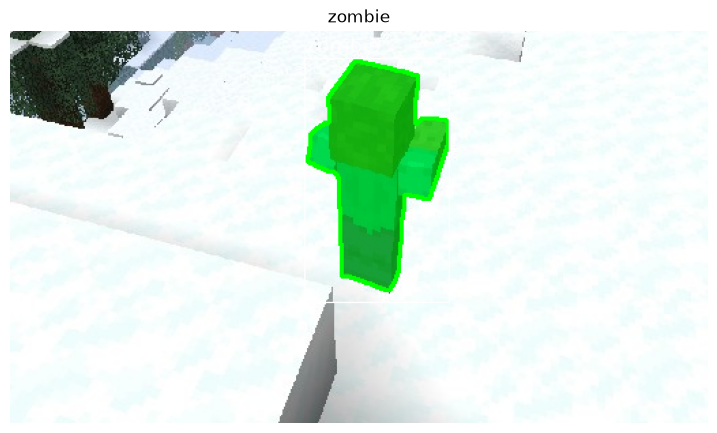

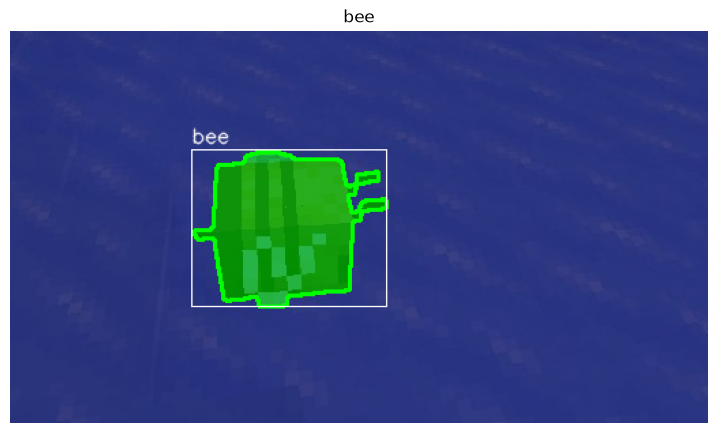

In [3]:
import yaml

ds = Path(cfg.get_dataset("minecraft_mobs-2")["dir"])
names = yaml.safe_load((ds / "data.yaml").read_text())["names"]
if isinstance(names, list):
    names = {i: n for i, n in enumerate(names)}

seen, picked = set(), []
for lf in sorted((ds / "test" / "labels").glob("*.txt")):
    text = lf.read_text().strip()
    if not text:
        continue
    cid = int(text.split()[0])
    if cid in seen:
        continue
    seen.add(cid)
    picked.append(lf)
    if len(picked) >= 6:
        break

for lf in picked:
    img = imread_unicode(ds / "test" / "images" / f"{lf.stem}.jpg")
    height, width = img.shape[:2]
    boxes, labels = [], []
    for line in lf.read_text().strip().splitlines():
        cid, cx, cy, w, h = line.split()
        cid = int(cid)
        cx, cy, w, h = map(float, (cx, cy, w, h))
        boxes.append([(cx - w / 2) * width, (cy - h / 2) * height,
                      (cx + w / 2) * width, (cy + h / 2) * height])
        labels.append(names.get(cid, str(cid)))
    res = sam(img, bboxes=boxes, device=DEVICE, verbose=False)
    masks = res[0].masks.data.cpu().numpy() if res[0].masks is not None else []
    show(overlay_masks(img, masks, boxes, labels), " / ".join(labels))

## 2. Pipeline: YOLO detection -> SAM

How it is applied: detect, then prompt SAM with the detected boxes.

detector classes: {0: 'creeper', 1: 'skeleton', 2: 'spider', 3: 'zombie'}
1 detection(s)


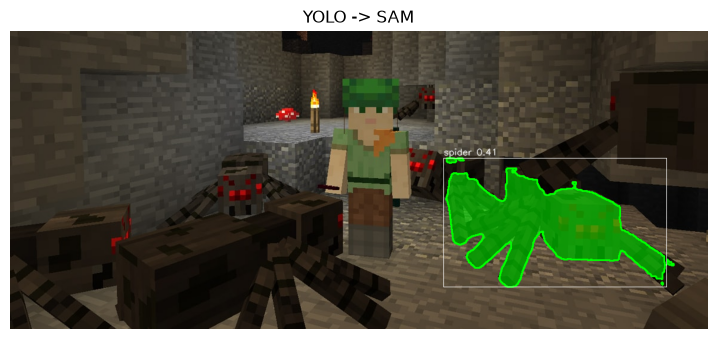

In [4]:
det = YOLO(str(DET_MODEL))
print("detector classes:", det.names)

img = imread_unicode(cfg.ROOT_DIR / "notebooks" / "tests" / "spiders.jpg")
r = det.predict(img, conf=0.25, device=DEVICE, verbose=False)[0]

boxes = r.boxes.xyxy.cpu().numpy()
labels = [f"{det.names[int(c)]} {float(cf):.2f}" for c, cf in zip(r.boxes.cls, r.boxes.conf)]
print(f"{len(boxes)} detection(s)")

masks = []
if len(boxes):
    res = sam(img, bboxes=boxes.tolist(), device=DEVICE, verbose=False)
    masks = res[0].masks.data.cpu().numpy()

show(overlay_masks(img, masks, boxes, labels), "YOLO -> SAM")

## 3. Highlight the segmented mob

Use the mask to dim the background or cut the object out.

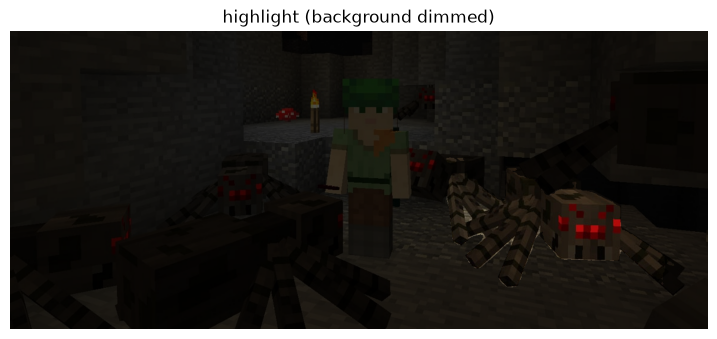

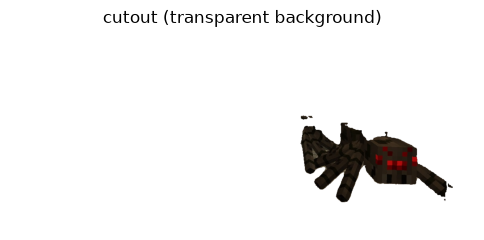

In [5]:
if len(masks):
    m = masks[0]
    show(highlight(img, m), "highlight (background dimmed)")

    cut = cutout_rgba(img, m)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(cut, cv2.COLOR_BGRA2RGBA))
    plt.axis("off")
    plt.title("cutout (transparent background)")
    plt.show()

## 4. Mask as polygon

Contour points to send to a web frontend as JSON.

In [6]:
if len(masks):
    poly = mask_to_polygon(masks[0])
    print(f"polygon points: {len(poly)}")
    print("first 5:", poly[:5])

polygon points: 606
first 5: [[834, 230], [832, 232], [832, 236], [833, 237], [833, 255]]


In [8]:
poly

[[834, 230],
 [832, 232],
 [832, 236],
 [833, 237],
 [833, 255],
 [832, 256],
 [832, 257],
 [831, 258],
 [831, 265],
 [832, 266],
 [832, 276],
 [831, 277],
 [831, 280],
 [830, 281],
 [830, 282],
 [828, 284],
 [827, 284],
 [826, 285],
 [824, 285],
 [823, 284],
 [821, 284],
 [820, 283],
 [819, 283],
 [818, 282],
 [817, 282],
 [813, 278],
 [813, 277],
 [812, 277],
 [811, 276],
 [809, 276],
 [808, 275],
 [807, 275],
 [806, 274],
 [805, 274],
 [802, 271],
 [801, 271],
 [799, 269],
 [799, 268],
 [798, 268],
 [797, 267],
 [796, 267],
 [792, 263],
 [792, 262],
 [791, 262],
 [785, 256],
 [785, 255],
 [784, 254],
 [784, 252],
 [783, 251],
 [783, 250],
 [782, 250],
 [781, 249],
 [779, 249],
 [778, 248],
 [770, 248],
 [767, 245],
 [767, 241],
 [766, 240],
 [766, 239],
 [765, 238],
 [763, 238],
 [762, 239],
 [752, 239],
 [751, 240],
 [750, 239],
 [749, 239],
 [748, 238],
 [744, 238],
 [743, 239],
 [742, 239],
 [740, 241],
 [740, 243],
 [739, 244],
 [739, 246],
 [737, 248],
 [737, 250],
 [736, 251],